# Progetto Architetture Dati: Impatto della Data Quality sui Modelli di Machine Learning
---
---

## 1. Obiettivo del Progetto di Architetture Dati

In ambito aziendale e nelle moderne architetture dati, raramente i modelli di Machine Learning in produzione vengono alimentati con dati perfetti. Sensori malfunzionanti, errori di join, bug nelle API o inserimenti manuali errati sporcano costantemente il flusso informativo.

L'obiettivo di questo progetto è **certificare la robustezza della nostra Rete Neurale** misurando empiricamente e statisticamente il degrado delle sue performance al variare della Data Quality. Il lavoro si articola nei seguenti 5 step:
### **1.1 Step Operativi**
Il lavoro è stato suddiviso in 5 fasi logiche:
1. **Preparazione e Baseline Analysis:** Isolamento della MLP, calcolo dell'accuratezza su dati puliti e ispezione della Feature Importance.
2. **Architettura del Degrado e Profilazione:** Studio di *Noise Injectors* per simulare errori nel database secondo le dimensioni di Data Quality
3. **Sperimentazione:** Sviluppo ed esecuzione degli stress, degradando progressivamente i dati di input come analizzato teoricamente nel capitolo precedente.
4. **Analisi Correlativa e Visualizzazione:** Studio della relazione tra metriche di qualità e calo della *Test Accuracy*.
5. **Conclusioni Finali:** Valutazione della tolleranza ai guasti del modello.

### **1.2 Architettura del Repository**
il progetto è strutturato come segue:

```text
Architetture-Dati-Progetto/
├── data/
│   └── dataset_ml_ready.csv       # Dataset originale 
├── docs/
│   └── Architetture-Dati report.ipynb      # Questo documento 
├── src/
│   └──  baseline_data_quality.py   # training e valutazione baseline
│   
├── requirements.txt               # Dipendenze 
└── README.md                      # Documentazione tecnica per l'esecuzione


---
---

## 2. Introduzione e Background: ATP Tennis Prediction

Il punto di partenza di questo elaborato è un progetto di Machine Learning precedentemente sviluppato, finalizzato alla previsione dell'esito dei match di tennis ATP dal 2000 al 2024. 

Nel progetto originale, abbiamo costruito una complessa pipeline di Data Preparation per estrarre e calcolare oltre 30 feature storiche e prestazionali per ogni giocatore. Tra le metriche più importanti figurano:
- **Differenziale ELO** globale e per superficie.
- **Forma Recente** misurata in percentuale di vittorie nelle ultime 5, 25 e 50 partite.
- **Metriche di Efficienza** rappresentate dalla percentuale di prime di servizio vincenti, palle break salvate.
- **Fattori Fisici** come età, altezza, mano dominantee.

Il modello definitivo scelto è stato una **Rete Neurale Multilayer Perceptron** con architettura `(128, 128, 64, 32)` e regolarizzazione `alpha=0.01`. Addestrata sui dati scalati dal 2000 al 2022, la rete ha raggiunto un'accuratezza solida e stabile (tra il 65% e il 71% a seconda delle configurazioni) sul Test Set comprendente tutte le partite degli anni 2023 e 2024. Infine è stato fatta una validazione finale calcolando l'accuracy del nostro modello simulando il torneo degli Australian Open 2025 e ottenendo gli stessi valori per le metriche riscontrate sul Test Set. 

Per maggiori dettagli sul modello utilizzato è stato incluso il report del progetto in doc/tennis-prediction report.ipynb e l'intero progetto è consultabile al link:  ---**INSERIAMO IL LINK DEL GITHUB** ---

---
---

## 3. Preparazione e Baseline Analysis

In questo primo stadio dell'esperimento, prepariamo l'infrastruttura tecnica e calcoliamo la **Baseline**. La Baseline rappresenta l'accuratezza del modello su dati "puliti" e servirà come termine di paragone per misurare il degrado delle performance nelle fasi successive. Al fine di una misurazione efficiente sono state estratte le sezioni di codice utili al nostro progetto dal progetto tennis-prediction e sono state racchiuse in metodi da poter chiamare all'occorrenza per gli allenamenti che verranno fatti durante ogni esperimento, e sono stati inseriti nello script baseline_data_quality.py.


### 3.1 Calcolo della Baseline
In questo primo step operativo, procediamo con l'importazione delle librerie fondamentali per la manipolazione dei dati (`pandas`, `numpy`) e per la costruzione della pipeline di Machine Learning tramite *scikit-learn* (`MLPClassifier`, `StandardScaler`). A livello architetturale, abbiamo definito una costante globale denominata `FEATURES` che contiene l'elenco esatto delle sole 34 variabili in input alla rete neurale che verranno usate per l'allenamento.

inoltre importiamo tre funzioni per garantirne la riusabilità durante i loop di test.

1. **`get_train_test_split`:**
   Questa funzione si occupa di caricare il dataset e separare i dati di addestramento da quelli di test. A livello metodologico, abbiamo optato per uno Split Temporale: usiamo i dati storici fino al 31/12/2022 per il training e blindiamo le stagioni 2023-2024 per il test. Questo approccio è fondamentale nei dati sportivi per evitare che il modello impari dal "futuro". Inoltre, gestisce fisiologici valori mancanti iniziali (`fillna(0)`).

2. **`train_and_evaluate_mlp`:**
   Questa funzione si occupa dell'addestramento del modello. Riceve i dati, applica la standardizzazione e addestra la nostra rete neurale di riferimento (`MLPClassifier` con architettura 128-128-64-32). 
   *Nota Architetturale:* È fondamentale osservare che lo `StandardScaler` viene "fittato" (`fit_transform`) **esclusivamente sul Training Set**. Il Test Set viene solo trasformato (`transform`). Questa accortezza previene **Data Leakage**, garantendo che la valutazione del modello sia non influenzata dai risultati.

3. **`get_or_compute_baseline`:**
   Questa funzione agisce come un sistema di persistenza su disco. Poiché l'addestramento della Baseline richiede tempo e produce sempre lo stesso risultato, la funzione verifica la presenza del risultato nel file locale `baseline.txt`. Se esiste, recupera il valore istantaneamente; in caso contrario, avvia l'addestramento e salva il risultato.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurazione per importare i nostri script dalla cartella 'src'
sys.path.append(os.path.abspath('../src'))

# Importiamo le funzioni dal nostro motore logico
from baseline_data_quality import get_train_test_split, train_and_evaluate_mlp, get_or_compute_baseline, FEATURES

All'interno di questo blocco andiamo ad eseguire il Training e il Testing del nostro modello, l'addestramento viene eseguito sui dati "puliti" e i log a schermo confermano il corretto partizionamento dei record. Il valore di `baseline_acc` ottenuto in questo passaggio diventerà la nostra "Baseline": il tetto massimo di performance rispetto al quale misureremo e valuteremo tutti i futuri degradi causati dalla scarsa Data Quality.

In [2]:
# ESECUZIONE PRINCIPALE

print("--- INIZIO PIPELINE DATA QUALITY ---")

# Calcolo dinamico del path rispetto alla posizione dello script (cartella 'src')
dataset_path = "../data/dataset_ml_ready.csv"
    
try:
    baseline_acc = get_or_compute_baseline(dataset_path)
    print(f"\nAccuracy Baseline = {baseline_acc:.4f}")
        
except FileNotFoundError:
    print(f"\nERRORE: file {dataset_path} non trovato")
except Exception as e:
    print(f"\nErrore durante l'esecuzione: {e}")

--- INIZIO PIPELINE DATA QUALITY ---

Accuracy Baseline = 0.6572


### 3.2 Studio delle Feature Importance
Prima di procedere con l'iniezione del rumore, è fondamentale comprendere come la Rete Neurale distribuisca il proprio "peso decisionale" sulle 34 variabili disponibili. Essendo la MLP (Multilayer Perceptron) un modello *Black Box*, utilizziamo la tecnica della **Permutation Importance** per svelarne le logiche interne.

Il processo consiste nel prendere una singola variabile all'interno del Test Set, rimescolarne casualmente i valori per distruggerne il senso logico, e misurare di quanto crolla l'accuratezza predittiva del modello. Più alto è il calo di accuratezza (visualizzato sull'asse X del grafico sottostante), maggiore è l'importanza di quella variabile. Le stanghette nere rappresentano la deviazione standard calcolata su 10 iterazioni di rimescolamento.

Dal grafico emerge chiaramente che il differenziale ELO (`DIFF_ELO`) è la metrica dominante. Tuttavia, si osserva che anche variabili come l'età (`diff_age`), la differenza di ranking (`ATP_RANK_DIFF`) e l'ELO sulla singola superficie (`DIFF_SURF_ELO`) possiedono un peso decisionale significativo. Questo significa che le informazioni fornite al modello sono in parte ridondanti: se una variabile dovesse subire gravi problemi di Data Quality, la Rete Neurale potrebbe essere in grado di compensare l'errore ri-distribuendo la sua attenzione sulle altre variabili correlate, arginando così il guasto sistemico.

Caricamento dati per ispezione...


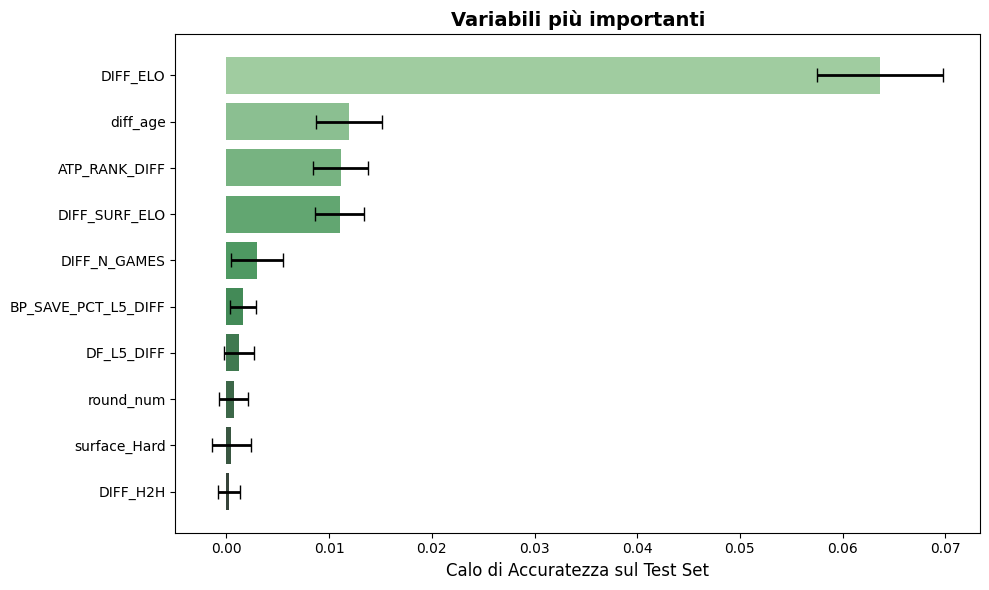

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

print("Caricamento dati per ispezione...")
dataset_path = "../data/dataset_ml_ready.csv"
X_train_clean, y_train_clean, X_test_clean, y_test_clean = get_train_test_split(dataset_path)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

mlp_baseline = MLPClassifier(hidden_layer_sizes=(128, 128, 64, 32), activation='relu', 
                             alpha=0.01, max_iter=150, random_state=42, early_stopping=True)
mlp_baseline.fit(X_train_scaled, y_train_clean)

result = permutation_importance(mlp_baseline, X_test_scaled, y_test_clean, n_repeats=10, random_state=42, n_jobs=-1)

importanza_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importanza': result.importances_mean,
    'Deviazione': result.importances_std
}).sort_values(by='Importanza', ascending=False)

top_features = importanza_df.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(x='Importanza', y='Feature', data=top_features, palette='Greens_d')

plt.errorbar(x=top_features['Importanza'], 
             y=np.arange(len(top_features)), 
             xerr=top_features['Deviazione'], 
             fmt='none', c='black', capsize=5, elinewidth=2)

plt.title('Variabili più importanti', fontsize=14, fontweight='bold')
plt.xlabel('Peso Decisionale (Impatto sull\'accuratezza)', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()

---
---
## 4. Architettura del degrado e Profilazione

Per valutare la robustezza e la capacità di generalizzazione della rete neurale e degli altri modelli, è stata sviluppata una pipeline dedicata alla perturbazione dei dati.  Questa procedura altera artificialmente il dataset introducendo anomalie controllate basate sulle dimensioni classiche della Data Quality: Accuratezza, Coerenza e Completezza, oltre all'inserimento di Rumore Gaussiano.

### 4.1 Accuratezza
L'accuratezza misura la corrispondenza tra i dati registrati e la realtà fisica o logica di riferimento. 

- Errori fisicamente impossibili: sono stati inseriti dei valori estremi nelle feature differenziali diff_ht (differenza altezza impostata ±150 cm) e diff_age (differenza di età impostata a ±80 anni). Questo test valuta la sensibilità della rete neurale rispetto a valori anomali e fuori distribuzione.
- Inversione della mano dominante: si modifica casualmente la feature invertendo il valore (da destro a mancino o viceversa), introducendo rumore su un attributo tecnico potenzialmente rilevante per l'esito del match.


In [ ]:
def eta_altezza(X, percentage):
    """
    Introduce errori di accuratezza (outliers) nelle differenze.
    - diff_ht: inserisce differenze estreme (es. +- 150cm)
    - diff_age: inserisce differenze impossibili (es. +- 80 anni)
    """
    X_dirty = X.copy()
    n_rows = len(X_dirty)
    n_changes = int(n_rows * percentage)
    
    # Selezioniamo gli indici casuali
    idx = np.random.choice(X_dirty.index, n_changes, replace=False)
    
    # Modifichiamo diff_ht (differenza altezza)
    X_dirty.loc[idx, 'diff_ht'] = np.random.choice([150.0, -150.0], size=n_changes)
    
    # Modifichiamo diff_age (differenza età)
    X_dirty.loc[idx, 'diff_age'] = np.random.choice([80.0, -80.0], size=n_changes)
    
    print(f"Modificati {n_changes} record per diff_ht e diff_age ({percentage*100}%).")
    return X_dirty

def mano_dominante(X, percentage):
    """
    Inverte la mano dominante (0 -> 1, 1 -> 0) per p1_is_left e p2_is_left.
    """
    X_dirty = X.copy()
    n_rows = len(X_dirty)
    n_changes = int(n_rows * percentage)
    
    for col in ['p1_is_left', 'p2_is_left']:
        idx = np.random.choice(X_dirty.index, n_changes, replace=False)
        # Operazione XOR o semplice inversione: se è 1 diventa 0, se è 0 diventa 1
        X_dirty.loc[idx, col] = 1 - X_dirty.loc[idx, col]
    
    print(f"Invertita la mano dominante nel {percentage*100}% dei record.")
    return X_dirty

### 4.2 Coerenza
La coerenza valuta se i dati rispettano le relazioni logiche attese nei dati del dominio del tennis. 
- Errori di disallineamento temporale: le date dei tornei sono state sostituite causalmente con dei valori estratti dall'interno del dataset, alterando la sequenza cronologica degli eventi.
- Paradosso Elo: per simulare differenti scenari di incoerenza dei dati, la funzione sporca_elo espone il dataset a tre stategie di perturbazione.
    1. Stategia zero: il valore di ELO viene azzerato completamente per la percentuale di righe campionata. Questo scenario simula una totale perdita dei dati. 
    2. Stragegia mean: sostutuisce l'ELO mancante con la media globale della colonna. 
    3. Stategia stale_50: utilizza una media basata sulle righe precedenti. Questa logica riproduce il fenomeno del Data Lag (dati obsoleti o non aggiornati in tempo reale), in cui il sistema assegna al giocatore una stima delle prestazioni precedenti anzichè quella calcolata sull'ultimo match giocato.

In [ ]:
def sporca_cronologia_date(X, percentage):
    """
    Simula errori di inserimento data scambiando i valori temporali 
    con date pescate casualmente dal dataset (out of order).
    """
    X_dirty = X.copy()
    # Cerchiamo colonne
    date_cols = [col for col in X_dirty.columns if any(x in col.lower() for x in ['tourney_date'])]
    
    if not date_cols:
        print("Nessuna colonna temporale trovata.")
        return X_dirty

    n_rows = len(X_dirty)
    n_changes = int(n_rows * percentage)

    for col in date_cols:
        idx_to_change = np.random.choice(X_dirty.index, n_changes, replace=False)
        # Peschiamo valori casuali dalla stessa colonna per creare l'anacronismo
        random_values = np.random.choice(X_dirty[col], size=n_changes, replace=True)
        X_dirty.loc[idx_to_change, col] = random_values
        
    print(f"Cronologia alterata per {date_cols} ({percentage*100}% dei record).")
    return X_dirty

def sporca_elo(X, percentage, strategy):
    """
    Introduce errori nell'Elo dei giocatori.
    Strategie supportate: 
    - 'zero': azzera il valore
    - 'mean': usa la media globale della colonna
    - 'stale_50': usa la media mobile delle 50 righe precedenti (simula dati vecchi)
    """
    X_dirty = X.copy()
    n_rows = len(X_dirty)
    n_changes = int(n_rows * percentage)
    
    elo_cols = [col for col in X_dirty.columns if 'elo' in col.lower()]
    
    for col in elo_cols:
        idx = np.random.choice(X_dirty.index, n_changes, replace=False)
        
        if strategy == 'zero':
            X_dirty.loc[idx, col] = 0.0
            
        elif strategy == 'mean':
            X_dirty.loc[idx, col] = X_dirty[col].mean()
            
        elif strategy == 'stale_50':
            # Creiamo una colonna temporanea con la media mobile
            # min_periods=1 assicura che calcoli anche per le prime 49 righe
            rolling_mean = X_dirty[col].rolling(window=50, min_periods=1).mean()
            # Sostituiamo solo gli indici selezionati con il valore "stagnante"
            X_dirty.loc[idx, col] = rolling_mean.loc[idx]
            
    print(f"Modificato Elo in {elo_cols} con strategia '{strategy}' ({percentage*100}%).")
    return X_dirty


### 4.3 Completezza
La completezza misura l'impatto della carenza di informazioni sul sistema predittivo. 
- Simulazione valori mancanti: una percentuale controllata di dati viene cancellata casualemnte all'interno del dataset tramite l'introduzione di valori NaN. 
- Simulazione dati non aggiornati: si crea uno scenario in cui i dati di un certo numero di match scelto non siano stati inseriti, simulando ritardi nei processi di aggiornamento delle informazioni.

In [ ]:
def introduci_missing_values(X, percentage):
    """
    Simula la mancanza di dati inserendo NaN casuali.
    - percentage: percentuale di celle totali da svuotare.
    """
    X_dirty = X.copy()
    # Creiamo una maschera booleana casuale
    mask = np.random.rand(*X_dirty.shape) < percentage
    X_dirty[mask] = np.nan
    
    print(f"Svuotato il {percentage*100}% delle celle totali del dataset.")
    return X_dirty

def sporca_elo_last(X, percentage, lag=10):
    """
    Simula un ritardo nell'aggiornamento dell'Elo.
    Sostituisce il valore attuale con quello di 'lag' posizioni precedenti.
    """
    X_dirty = X.copy()
    n_rows = len(X_dirty)
    n_changes = int(n_rows * percentage)
    
    # Selezioniamo le colonne che contengono 'elo'
    elo_cols = [col for col in X_dirty.columns if 'elo' in col.lower()]
    
    for col in elo_cols:
        # Creiamo una serie con i valori traslati (quelli di 10 righe fa)
        # shift(lag) sposta i dati, bfill() riempie i primi 10 buchi con il primo valore disponibile
        stale_values = X_dirty[col].shift(lag).bfill()
        
        # Scegliamo gli indici da sporcare
        idx = np.random.choice(X_dirty.index, n_changes, replace=False)
        
        # Sostituiamo i valori attuali con quelli vecchi
        X_dirty.loc[idx, col] = stale_values.loc[idx]
        
    print(f"Simulato ritardo di {lag} partite per l'Elo ({percentage*100}% dei record).")
    return X_dirty
